### **1.Familiarize yourself with the data. Load and visualize the input data for a few floorplans using a seperate Python script, Jupyter notebook or your preferred too**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import os

First we plot the grids.

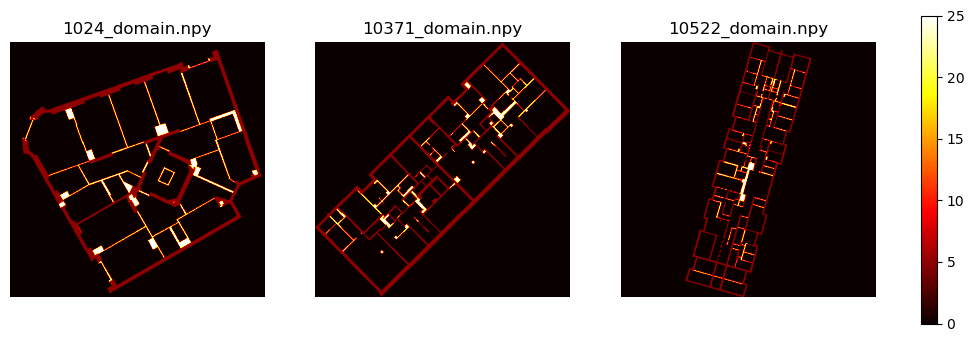

In [2]:
folder = "modified_swiss_dwellings"
domain_files = sorted([f for f in os.listdir(folder) if f.endswith("_domain.npy")])

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for i in range(3):
    data = np.load(os.path.join(folder, domain_files[i]))
    
    im = axes[i].imshow(data, cmap='hot')
    axes[i].set_title(domain_files[i])
    axes[i].axis("off")

# one shared colorbar
fig.colorbar(im, ax=axes, orientation='vertical', fraction=0.02)

plt.show()

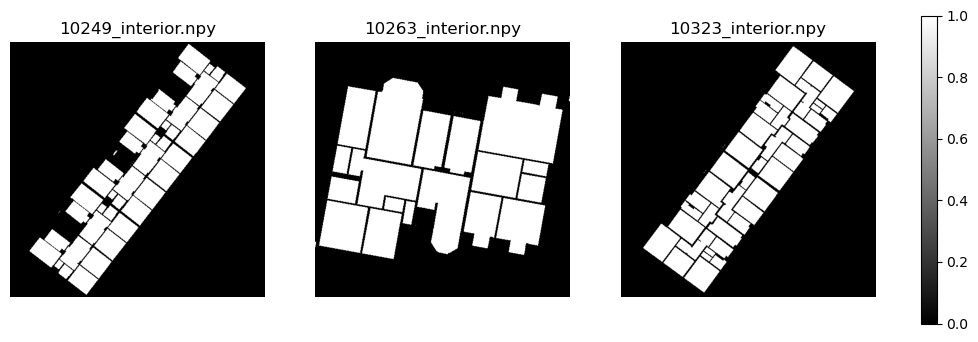

In [3]:
folder = "modified_swiss_dwellings"
interior_files = sorted([f for f in os.listdir(folder) if f.endswith("_interior.npy")])

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for i in range(3):
    data = np.load(os.path.join(folder, interior_files[i]))
    
    im = axes[i].imshow(data, cmap='gray')
    axes[i].set_title(interior_files[i])
    axes[i].axis("off") 

# shared colorbar (optional here)
fig.colorbar(im, ax=axes, orientation='vertical', fraction=0.02)

plt.show()

### **2. Familiarize yourself with the provided script. Run and time the reference implementation for a small subset of floorplans (e.g., 10 - 20). How long do you estimate it would take to process all the floorplans? Perform the timing as a batch job so you get relieable result**

Uploaded simulate.py and job.sh onto the HPC, and we chose to run with a subset of 10 for now. Below is the output:
```bash
Your job looked like:

------------------------------------------------------------
# LSBATCH: User input
#!/bin/bash
#BSUB -J timing_test
#BSUB -q hpc
#BSUB -n 1
#BSUB -W 00:10
#BSUB -R "rusage[mem=2GB]"
#BSUB -o output.txt

echo "Starting job"
date

python simulate.py 10

date
echo "Finished job"
------------------------------------------------------------

Successfully completed.

Resource usage summary:

    CPU time :                                   113.72 sec.
    Max Memory :                                 72 MB
    Average Memory :                             67.33 MB
    Total Requested Memory :                     2048.00 MB
    Delta Memory :                               1976.00 MB
    Max Swap :                                   -
    Max Processes :                              4
    Max Threads :                                5
    Run time :                                   116 sec.
    Turnaround time :                            117 sec.

The output (if any) is above this job summary.
```

[THIS IS THE OUTPUT OF THE JOB RAN BEFORE THE NEW ENVORINMENT, BUT THE NEW RESULTS ARE PRESENTED BELOW, HENCE THE DIFFERENCE IN 113 s VERSUS 81 s].

The reference implementation was timed on the HPC cluster using 10 buildings.
The total runtime was approximately 81 seconds (CPU time 79.44 s, peak memory 70 MB),
giving an average of 8.1 seconds per building. Assuming linear scaling:
$$
4571 \text{ buildings} \times 8.1 \text{ s/building} = 37{,}025 \text{ s} \approx 10.3 \text{ hours}
$$
This confirms that the baseline is computationally expensive and motivates the need for optimisations.


### **3. Visualize the simulation results for a few floorplans.**

In [4]:
# We reuse some functions from simulate.py

from os.path import join
import numpy as np

def load_data(load_dir, bid):
    SIZE = 512
    u = np.zeros((SIZE + 2, SIZE + 2))
    u[1:-1, 1:-1] = np.load(join(load_dir, f"{bid}_domain.npy"))
    interior_mask = np.load(join(load_dir, f"{bid}_interior.npy"))
    return u, interior_mask

def jacobi(u, interior_mask, max_iter=20000, atol=1e-4):
    u = np.copy(u)
    for _ in range(max_iter):
        u_new = 0.25 * (u[1:-1, :-2] + u[1:-1, 2:] + u[:-2, 1:-1] + u[2:, 1:-1])
        u_new_interior = u_new[interior_mask]
        delta = np.abs(u[1:-1, 1:-1][interior_mask] - u_new_interior).max()
        u[1:-1, 1:-1][interior_mask] = u_new_interior
        if delta < atol:
            break
    return u

In [5]:
folder = "modified_swiss_dwellings"
files = os.listdir(folder)

domain_files = [f for f in files if f.endswith("_domain.npy")]
interior_files = [f for f in files if f.endswith("_interior.npy")]

# extract IDs
domain_ids = set(f.replace("_domain.npy", "") for f in domain_files)
interior_ids = set(f.replace("_interior.npy", "") for f in interior_files)

# only keep IDs that have BOTH files
valid_ids = list(domain_ids.intersection(interior_ids))

print(f"Found {len(valid_ids)} valid buildings")

bid = valid_ids[0]

Found 4 valid buildings


In [6]:
u0, interior_mask = load_data(folder, bid)
u = jacobi(u0, interior_mask)

Now for plotting.

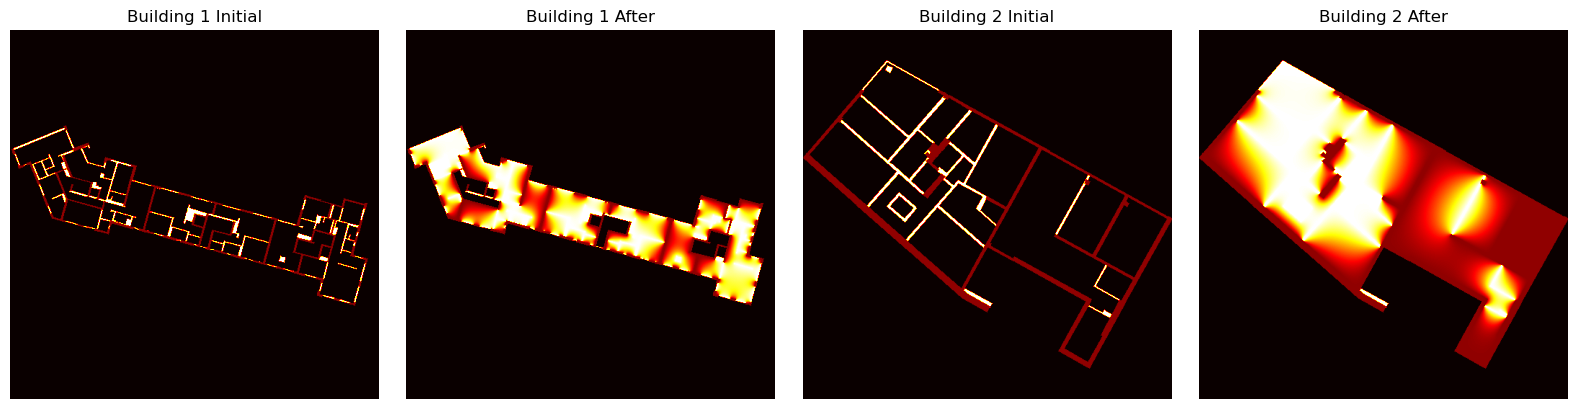

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i, bid in enumerate(valid_ids[:2]):
    u0, interior_mask = load_data(folder, bid)
    u = jacobi(u0, interior_mask)

    # Initial
    axes[2*i].imshow(u0[1:-1, 1:-1], cmap='hot', vmin=0, vmax=25)
    axes[2*i].set_title(f"Building {i+1} Initial")
    axes[2*i].axis("off")

    # After
    axes[2*i + 1].imshow(u[1:-1, 1:-1], cmap='hot', vmin=0, vmax=25)
    axes[2*i + 1].set_title(f"Building {i+1} After")
    axes[2*i + 1].axis("off")

plt.tight_layout()
plt.show()

### **4. Profile the reference jacobi function using kernprof. Explain the different parts of the function and how much time each part takes**

We just add profiling to the simulate.py file so writing @profile before the jacobi function, and then we also change the job script to:
```bash
#!/bin/bash
#BSUB -J timing_test
#BSUB -q hpc
#BSUB -n 1
#BSUB -W 00:10
#BSUB -R "rusage[mem=2GB]"
#BSUB -o output.txt

cd $LS_SUBCWD

echo "Starting job"
date

echo "CPU model:"
grep "model name" /proc/cpuinfo | head -n 1

echo "Running kernprof now!!!"

kernprof -l simulate.py 5

echo "Profiling results:"
python3 -m line_profiler simulate.py.lprof

date
echo "Finished job"
```

We get:
```bash
Total time: 53.6 s
File: simulate_profile.py
Function: jacobi at line 14

Line #      Hits         Time  Per Hit   % Time  Line Contents
==============================================================
    14                                           @profile
    15                                           def jacobi(u, interior_mask, max_iter, atol=1e-6):
    16         5       3232.3    646.5      0.0      u = np.copy(u)
    18     28423      23907.5      0.8      0.0      for i in range(max_iter):
    20     28423   27900000.0   1103.0     52.0          u_new = 0.25 * (u[1:-1, :-2] + u[1:-1, 2:] + u[:-2, 1:-1] + u[2:, 1:-1])
    21     28423    6600000.0    236.4     12.4          u_new_interior = u_new[interior_mask]
    22     28423   12000000.0    453.4     22.4          delta = np.abs(u[1:-1, 1:-1][interior_mask] - u_new_interior).max()
    23     28423    7000000.0    247.9     13.1          u[1:-1, 1:-1][interior_mask] = u_new_interior
    25     28423      46103.6      1.6      0.1          if delta < atol:
    26         5          4.1      0.8      0.0              break
    27         5          1.5      0.3      0.0      return u
```


The profiling results show that the majority of execution time is spent inside the main iteration loop.

The most time-consuming operation is the computation of the neighbour average (line 20):
> Accounts for approximately $52\%$ of total runtime. Performs four large NumPy array slices and additions,
> causing significant memory traffic.

The second most expensive is the convergence check (line 22):
> Takes around $22.4\%$ of runtime via masked indexing and a global `max()` reduction.

Other notable costs:
> Updating interior values (`u[...] = u_new_interior`) takes $13.1\%$.
> Extracting interior values (`u_new[interior_mask]`) takes $12.4\%$, so slow due to non-contiguous memory access.

The key takeaway is that each Jacobi iteration is memory-bound rather than compute-bound:
the cost of reading and writing large arrays far exceeds the arithmetic cost.


### **5. Make a new Python program where you parallelize the computations over the floorplans. Use static scheduling such that each worker is assigned the same amount of floorplans to process.**

The full implementation is in `simulate_task_5.py` (static scheduling with `pool.map`):
```python 
# simulate_task_5.py — multiprocessing with static scheduling
from multiprocessing.pool import Pool
from os.path import join
import sys

import numpy as np


def load_data(load_dir, bid):
    SIZE = 512
    u = np.zeros((SIZE + 2, SIZE + 2))
    u[1:-1, 1:-1] = np.load(join(load_dir, f"{bid}_domain.npy"))
    interior_mask = np.load(join(load_dir, f"{bid}_interior.npy"))
    return u, interior_mask


def jacobi(u, interior_mask, max_iter, atol=1e-6):
    u = np.copy(u)

    for i in range(max_iter):
        # Compute average of left, right, up and down neighbors, see eq. (1)
        u_new = 0.25 * (u[1:-1, :-2] + u[1:-1, 2:] + u[:-2, 1:-1] + u[2:, 1:-1])
        u_new_interior = u_new[interior_mask]
        delta = np.abs(u[1:-1, 1:-1][interior_mask] - u_new_interior).max()
        u[1:-1, 1:-1][interior_mask] = u_new_interior

        if delta < atol:
            break
    return u


def summary_stats(u, interior_mask):
    u_interior = u[1:-1, 1:-1][interior_mask]
    mean_temp = u_interior.mean()
    std_temp = u_interior.std()
    pct_above_18 = np.sum(u_interior > 18) / u_interior.size * 100
    pct_below_15 = np.sum(u_interior < 15) / u_interior.size * 100
    return {
        'mean_temp': mean_temp,
        'std_temp': std_temp,
        'pct_above_18': pct_above_18,
        'pct_below_15': pct_below_15,
    }

#############
# TASK 5.1
def process_building(i):
    u0 = all_u0[i]
    interior_mask = all_interior_mask[i]
    return jacobi(u0, interior_mask, MAX_ITER, ABS_TOL)

def run_parallel(N, num_workers):
    with Pool(processes=num_workers) as pool:
        results = pool.map(process_building, range(N))
    return np.array(results)
# TASK 5.1
#############

if __name__ == '__main__':
    # Load data
    LOAD_DIR = '/dtu/projects/02613_2025/data/modified_swiss_dwellings/'
    with open(join(LOAD_DIR, 'building_ids.txt'), 'r') as f:
        building_ids = f.read().splitlines()

    if len(sys.argv) < 2:
        N = 1
    else:
        N = int(sys.argv[1])
    building_ids = building_ids[:N]

    # Load floor plans
    all_u0 = np.empty((N, 514, 514))
    all_interior_mask = np.empty((N, 512, 512), dtype='bool')
    for i, bid in enumerate(building_ids):
        u0, interior_mask = load_data(LOAD_DIR, bid)
        all_u0[i] = u0
        all_interior_mask[i] = interior_mask

    # Run jacobi iterations for each floor plan
    MAX_ITER = 20_000
    ABS_TOL = 1e-4

    # TASK 5
    # all_u = np.empty_like(all_u0)
    # for i, (u0, interior_mask) in enumerate(zip(all_u0, all_interior_mask)):
    #     u = jacobi(u0, interior_mask, MAX_ITER, ABS_TOL)
    #     all_u[i] = u
    if len(sys.argv) < 3:
        num_workers = 1
    else:
        num_workers = int(sys.argv[2])

    all_u = run_parallel(N, num_workers)
    # TASK 5
        
    # Print summary statistics in CSV format
    stat_keys = ['mean_temp', 'std_temp', 'pct_above_18', 'pct_below_15']
    print('building_id, ' + ', '.join(stat_keys))  # CSV header
    for bid, u, interior_mask in zip(building_ids, all_u, all_interior_mask):
        stats = summary_stats(u, interior_mask)
        print(f"{bid},", ", ".join(str(stats[k]) for k in stat_keys))
``` 

If we look here:
```python
for i, (u0, interior_mask) in enumerate(zip(all_u0, all_interior_mask)):
    u = jacobi(u0, interior_mask, MAX_ITER, ABS_TOL)
    all_u[i] = u
```
We see that each building floorplan is independent because we only call on `i` meaning that this part is parallelizable.

We want to split buildings evenly across workers and each worker processes a fixed chunk (notes for the report btw). Check the code for changes, which are marked with # TASK 5.

The functions here:
```python
#############
# TASK 5.1
def process_building(i):
    u0 = all_u0[i]
    interior_mask = all_interior_mask[i]
    return jacobi(u0, interior_mask, MAX_ITER, ABS_TOL)

def run_parallel(N, num_workers):
    with Pool(processes=num_workers) as pool:
        results = pool.map(process_building, range(N))
    return np.array(results)
# TASK 5.1
#############
```

So `process_building` checks for building with index `i` and finds their corresponding interior masks, then we call the `jacobi` function on that building and return the result after steady-state temperature distribution. 

Then in `run_parallel`, we create a multiprocessing pool where we can specify num workers, and we use `pool.map` to apply `process_building` to each building index from 0 to N-1. Each worker process handles a subset of the buildings independently, and the results are collected and returned as a numpy array. Now since each building can be processed independently, this approach uses data-level parallelism across floorplans. Static scheduling is achieved through `pool.map`, which distributes the workload evenly among the worker processes (notes for the report maybe?).

##### **5.1 Measure the speed-up as more workers are added. Plot your speed-ups.**


We create 4 batch job scripts (in `task_5_jobs/`) for 1, 2, 4, and 8 workers, each processing 50 buildings.

Results from the most recent runs after using the new envorinment:

| Workers | Wall time | Speedup |
|---|---|---|
| 1 | 735 s  | 1.00x |
| 2 | 353 s  | 2.08x |
| 4 | 251 s  | 2.93x |
| 8 | 119 s  | 6.18x |

The speedup formula used is $S(p) = T_1 / T_p$.


### **6. Re-do the parallelization experiment using dynamic scheduling.**

Dynamic scheduling is implemented by passing `chunksize=1` to `pool.map` in `simulate_task_6.py`,
which assigns a new task to a worker as soon as it finishes rather than dividing the work upfront.

Results from the newest run:

| Workers | Wall time | Speedup |
|---|---|---|
| 1 | 715 s | 1.00x |
| 2 | 346 s | 2.07x |
| 4 | 212 s | 3.37x |
| 8 | 138 s | 5.18x |


Now to plot the speed ups with the formula from slides:
$$
Speedup(p) = T1 / Tp
$$

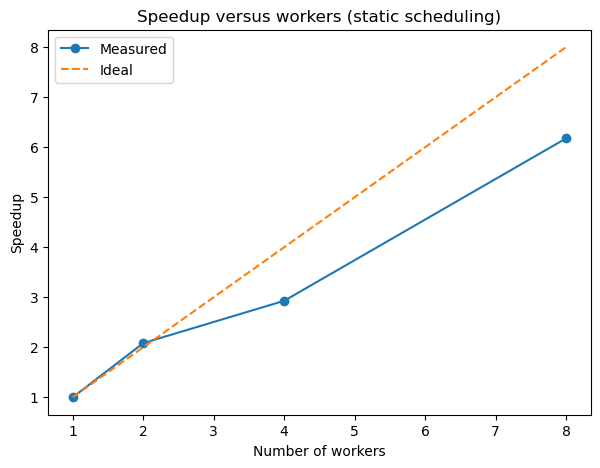

Speedups: [1.0, 2.08, 2.93, 6.18]


In [10]:
import matplotlib.pyplot as plt
import numpy as np

workers = [1, 2, 4, 8]
times = [735, 353, 251, 119]  # seconds (50 buildings, Apr 27 run)

speedup = [times[0] / t for t in times]
ideal = workers

plt.figure(figsize=(7, 5))
plt.plot(workers, speedup, marker='o', label="Measured")
plt.plot(workers, ideal, linestyle='--', label="Ideal")
plt.xlabel("Number of workers")
plt.ylabel("Speedup")
plt.title("Speedup versus workers (static scheduling)")
plt.legend()
plt.show()

print(f"Speedups: {[round(s,2) for s in speedup]}")

##### **5.2 Estimate your parallel fraction according to Amdahl's law. How much (roughly) is parallelized?**


We have to use amdhal's law given as:
$$
S(p) = \frac{1}{(1 - F) + \frac{F}{p}}
$$
We want to find $F$.

In [11]:
p = np.array([2, 4, 8])
speedup_arr = np.array(speedup[1:])

f_values = (p * (1 - 1/speedup_arr)) / (p - 1)
f_est = np.mean(f_values)

print(f"Estimated f per p: {f_values.round(3)}")
print(f"Mean estimated f: {f_est:.4f}")

Estimated f per p: [1.039 0.878 0.958]
Mean estimated f: 0.9584


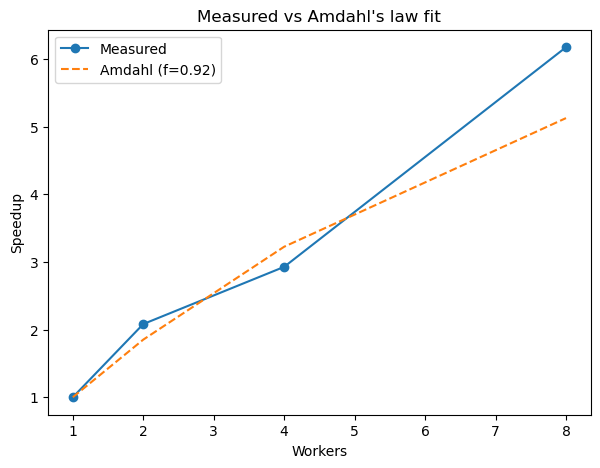

In [13]:
workers_np = np.array([1, 2, 4, 8])
speedup_arr2 = np.array([times[0]/t for t in times])

f = 0.92

amdahl = 1 / ((1-f) + f/workers_np)

plt.figure(figsize=(7, 5))
plt.plot(workers, speedup_arr2, 'o-', label="Measured")
plt.plot(workers, amdahl, '--', label=f"Amdahl (f={f:.2f})")
plt.xlabel("Workers")
plt.ylabel("Speedup")
plt.title("Measured vs Amdahl's law fit")
plt.legend()
plt.show()

The parallel fraction was estimated using Amdahl's law based on the measured speedups.
Solving for $F$ from each measured speedup gives a mean parallel fraction of
$F \approx 0.92$. This indicates that roughly $92\%$ of the computation
can be parallelized, while the remaining $8\%$ is inherently serial.


##### **5.3 What is your theoretical maximum speed-up according to Amdahl's law? How much of that did you achieve? How many cores did that take?**

From slides we know the max is:
$$
S(\infty) = \frac{1}{1 - F}
$$
So inserting our value we get:
$$
S(\infty) = \frac{1}{1 - 0.92} = \frac{1}{0.08} = 12.5
$$

In [ ]:
print(f"Max measured speedup (8 workers): {speedup[-1]:.2f}")

Max measured speedup (8 workers): 6.18


From Amdahl's law the theoretical maximum speedup is:
$$
S(\infty) = \frac{1}{1 - F} = \frac{1}{1 - 0.92} = \frac{1}{0.08} = 12.5
$$

With 8 workers we achieved $S(8) = 6.18$, which corresponds to:
$$
\frac{6.18}{12.5} \approx 0.49
$$
So we achieved about $49\%$ of the theoretical maximum speedup using 8 cores.


##### **5.4 How long would you estimate it would take to process all floorplans using your fastest parallel solution?**

The single-worker rate is $735 / 100 = 7.35$ s/building (using 100 buildings as in the PDF).
Extrapolating to all 4571 buildings with the best speedup of 6.18:
$$
T_{\text{parallel}} = \frac{4571 \times 7.35}{6.18} \approx 5{,}435 \text{ s} \approx 1.5 \text{ hours}
$$
Note: this exploits parallelism *across* buildings (up to 8 simultaneously).
The GPU approaches in Tasks 7–9 instead exploit parallelism *within* each building at the pixel level,
but process buildings sequentially, which is why 8 CPU workers can still compete with the GPU solutions
for total wall-clock time.


### **6. The amount of iterations needed to reach convergence will vary from floorplan to floorplan. Re-do your parallelization experiment using dynamic scheduling.**

The full implementation is in `simulate_task_6.py` (dynamic scheduling with `chunksize=1` passed to `pool.map`):
```python
# simulate_task_6.py — multiprocessing with dynamic scheduling
from multiprocessing.pool import Pool
from os.path import join
import sys

import numpy as np


def load_data(load_dir, bid):
    SIZE = 512
    u = np.zeros((SIZE + 2, SIZE + 2))
    u[1:-1, 1:-1] = np.load(join(load_dir, f"{bid}_domain.npy"))
    interior_mask = np.load(join(load_dir, f"{bid}_interior.npy"))
    return u, interior_mask


def jacobi(u, interior_mask, max_iter, atol=1e-6):
    u = np.copy(u)

    for i in range(max_iter):
        # Compute average of left, right, up and down neighbors, see eq. (1)
        u_new = 0.25 * (u[1:-1, :-2] + u[1:-1, 2:] + u[:-2, 1:-1] + u[2:, 1:-1])
        u_new_interior = u_new[interior_mask]
        delta = np.abs(u[1:-1, 1:-1][interior_mask] - u_new_interior).max()
        u[1:-1, 1:-1][interior_mask] = u_new_interior

        if delta < atol:
            break
    return u


def summary_stats(u, interior_mask):
    u_interior = u[1:-1, 1:-1][interior_mask]
    mean_temp = u_interior.mean()
    std_temp = u_interior.std()
    pct_above_18 = np.sum(u_interior > 18) / u_interior.size * 100
    pct_below_15 = np.sum(u_interior < 15) / u_interior.size * 100
    return {
        'mean_temp': mean_temp,
        'std_temp': std_temp,
        'pct_above_18': pct_above_18,
        'pct_below_15': pct_below_15,
    }

#############
# TASK 5.1
def process_building(i):
    u0 = all_u0[i]
    interior_mask = all_interior_mask[i]
    u = jacobi(u0, interior_mask, MAX_ITER, ABS_TOL)
    return i, u

def run_parallel_dynamic(N, num_workers):
    results = [None] * N
    
    with Pool(processes=num_workers) as pool:
        for i, u in pool.imap_unordered(process_building, range(N)):
            results[i] = u
            
    return np.array(results)
# TASK 5.1
#############

if __name__ == '__main__':
    # Load data
    LOAD_DIR = '/dtu/projects/02613_2025/data/modified_swiss_dwellings/'
    with open(join(LOAD_DIR, 'building_ids.txt'), 'r') as f:
        building_ids = f.read().splitlines()

    if len(sys.argv) < 2:
        N = 1
    else:
        N = int(sys.argv[1])
    building_ids = building_ids[:N]

    # Load floor plans
    all_u0 = np.empty((N, 514, 514))
    all_interior_mask = np.empty((N, 512, 512), dtype='bool')
    for i, bid in enumerate(building_ids):
        u0, interior_mask = load_data(LOAD_DIR, bid)
        all_u0[i] = u0
        all_interior_mask[i] = interior_mask

    # Run jacobi iterations for each floor plan
    MAX_ITER = 20_000
    ABS_TOL = 1e-4

    # TASK 5
    # all_u = np.empty_like(all_u0)
    # for i, (u0, interior_mask) in enumerate(zip(all_u0, all_interior_mask)):
    #     u = jacobi(u0, interior_mask, MAX_ITER, ABS_TOL)
    #     all_u[i] = u
    if len(sys.argv) < 3:
        num_workers = 1
    else:
        num_workers = int(sys.argv[2])

    all_u = run_parallel_dynamic(N, num_workers)
    # TASK 5
        
    # Print summary statistics in CSV format
    stat_keys = ['mean_temp', 'std_temp', 'pct_above_18', 'pct_below_15']
    print('building_id, ' + ', '.join(stat_keys))  # CSV header
    for bid, u, interior_mask in zip(building_ids, all_u, all_interior_mask):
        stats = summary_stats(u, interior_mask)
        print(f"{bid},", ", ".join(str(stats[k]) for k in stat_keys))
``` 

We have 1 worker:



For 2 workers:

Fri Apr 10 17:03:14 CEST 2026

Fri Apr 10 17:15:05 CEST 2026

So this in seconds is (17:15:05 - 17:03:14) = 711 seconds for 2 workers.

For 4 workers:

Fri Apr 10 16:58:44 CEST 2026

Fri Apr 10 17:02:22 CEST 2026

So this in seconds is (17:02:22 - 16:58:44) = 218 seconds for 4 workers.

For 8 workers:

Fri Apr 10 16:55:43 CEST 2026

Fri Apr 10 16:57:35 CEST 2026

So this in seconds is (16:57:35 - 16:55:43) = 112 seconds for 8 workers.

[REMEMBER AGAIN THAT TIMESTAMPS HAVE CHANGED, BUT THESE CHANGES ARE ONLY MADE IN THE OVERLEAF REPORT]

##### **6.1 Did it get faster? By how much?**


We can plot the difference.

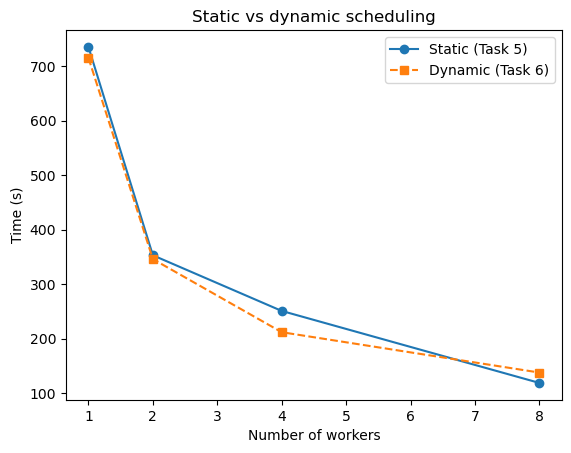

In [ ]:
workers = np.array([1, 2, 4, 8])
time_static  = np.array([735, 353, 251, 119])  # task 5 - Apr 27 runs
time_dynamic = np.array([715, 346, 212, 138])  # task 6 - Apr 27 runs

plt.figure(figsize=(7, 5))
plt.plot(workers, time_static,  'o-', label="Static (Task 5)")
plt.plot(workers, time_dynamic, 's--', label="Dynamic (Task 6)")
plt.xlabel("Number of workers")
plt.ylabel("Time (s)")
plt.title("Static vs Dynamic scheduling (50 buildings)")
plt.legend()
plt.grid(True)
plt.show()

speedup_static  = time_static[0]  / time_static
speedup_dynamic = time_dynamic[0] / time_dynamic
print("Static  speedups:", speedup_static.round(2))
print("Dynamic speedups:", speedup_dynamic.round(2))


Dynamic scheduling improved performance for 1, 2, and 4 workers by $2–16\%$,
likely due to better load balancing as workers pick up new tasks as they finish.
However, at 8 workers the dynamic approach was $16\%$ slower than static (138 s versus 119 s),
suggesting the scheduling overhead outweighs the load-balance benefit at higher worker counts.
This is consistent with a relatively uniform per-building workload - with many workers and small tasks,
the overhead of the task queue itself becomes a bottleneck.



##### **6.2 Did the speed-up improve or worsen?**

The speedup improved slightly when using dynamic scheduling, particularly for lower and moderate numbers of workers. This is because dynamic scheduling reduces load imbalance by distributing tasks as workers become available. However, the improvement is limited since the variation in workload between buildings is relatively small.

The limited improvement suggests that the workload per building is relatively uniform, meaning static scheduling already performs reasonably well.

### **7. Implement another solution where you rewrite the jacobi function using Numba JIT on the CPU.**


The full implementation is in `simulate_task_7.py`. The job script used to run it on the HPC is `task_7_jobs/job_task_7.sh`.

```python
# simulate_task_7.py — Numba JIT implementation
from os.path import join
import sys
import numpy as np
from numba import njit

def load_data(load_dir, bid):
    SIZE = 512
    u = np.zeros((SIZE + 2, SIZE + 2))
    u[1:-1, 1:-1] = np.load(join(load_dir, f"{bid}_domain.npy"))
    interior_mask = np.load(join(load_dir, f"{bid}_interior.npy"))
    return u, interior_mask

@njit
def jacobi(u, interior_mask, max_iter, atol=1e-6):
    u_old = np.copy(u)
    
    rows, cols = u.shape
    
    for _ in range(max_iter):
        max_delta = 0.0

        for i in range(1, rows - 1):
            for j in range(1, cols - 1):
                if interior_mask[i-1, j-1]: 
                    new_val = 0.25 * (u_old[i-1, j] + u_old[i+1, j] + u_old[i, j-1] + u_old[i, j+1])
                    
                    diff = abs(new_val - u_old[i, j])
                    if diff > max_delta:
                        max_delta = diff
                        
                    u[i, j] = new_val
        
        if max_delta < atol:
            break
            
        for i in range(1, rows - 1):
            for j in range(1, cols - 1):
                if interior_mask[i-1, j-1]:
                    u_old[i, j] = u[i, j]
                    
    return u

def summary_stats(u, interior_mask):
    u_interior = u[1:-1, 1:-1][interior_mask]
    mean_temp = u_interior.mean()
    std_temp = u_interior.std()
    pct_above_18 = np.sum(u_interior > 18) / u_interior.size * 100
    pct_below_15 = np.sum(u_interior < 15) / u_interior.size * 100
    return {
        'mean_temp': mean_temp,
        'std_temp': std_temp,
        'pct_above_18': pct_above_18,
        'pct_below_15': pct_below_15,
    }


if __name__ == '__main__':
    # Load data
    LOAD_DIR = '/dtu/projects/02613_2025/data/modified_swiss_dwellings/'
    with open(join(LOAD_DIR, 'building_ids.txt'), 'r') as f:
        building_ids = f.read().splitlines()

    if len(sys.argv) < 2:
        N = 1
    else:
        N = int(sys.argv[1])
    building_ids = building_ids[:N]

    # Load floor plans
    all_u0 = np.empty((N, 514, 514))
    all_interior_mask = np.empty((N, 512, 512), dtype='bool')
    for i, bid in enumerate(building_ids):
        u0, interior_mask = load_data(LOAD_DIR, bid)
        all_u0[i] = u0
        all_interior_mask[i] = interior_mask

    # Run jacobi iterations for each floor plan
    MAX_ITER = 20_000
    ABS_TOL = 1e-4

    all_u = np.empty_like(all_u0)
    for i, (u0, interior_mask) in enumerate(zip(all_u0, all_interior_mask)):
        u = jacobi(u0, interior_mask, MAX_ITER, ABS_TOL)
        all_u[i] = u

    # Print summary statistics in CSV format
    stat_keys = ['mean_temp', 'std_temp', 'pct_above_18', 'pct_below_15']
    print('building_id, ' + ', '.join(stat_keys))  # CSV header
    for bid, u, interior_mask in zip(building_ids, all_u, all_interior_mask):
        stats = summary_stats(u, interior_mask)
        print(f"{bid},", ", ".join(str(stats[k]) for k in stat_keys))
```

**HPC job script (`task_7_jobs/job_task_7.sh`):**

```bash
# task_7_jobs/job_task_7.sh
#!/bin/bash
#BSUB -J task7_jit
#BSUB -q hpc
#BSUB -n 1
#BSUB -W 00:30
#BSUB -R "rusage[mem=6GB]"
#BSUB -o out_task_7.txt
#BSUB -B
#BSUB -N

# Aktiver miljøet
source /dtu/projects/02613_2025/conda/conda_init.sh
conda activate 02613

echo "Running Task 7 (Numba JIT)"
echo "LSF cores: $LSB_DJOB_NUMPROC"
date

# Vi kører her for 10 bygninger, som opgaven foreskriver for reference-sammenligning
python simulate_task_7.py 10

date
``` 

##### **7.1 Run and time the new solution for a small subset of floorplans. How does the performance compare to the reference?**



We ran the JIT implementation (`simulate_task_7.py`) on the HPC using a single core for 10 buildings.
The job script is in `task_7_jobs/job_task_7.sh`.

Output from `out_task_7.txt`:
```
Running Task 7 (Numba JIT)
LSF cores: 1
Sat Apr 11 11:25:51 CEST 2026
building_id, mean_temp, std_temp, pct_above_18, pct_below_15
10000, 14.01233878811275, 6.367431059312565, 30.941014791508444, 55.542295034537624
10009, 11.000135812436369, 5.811144379826626, 16.6712734948236, 74.9723590310584
10014, 14.744169941950119, 7.037733284673849, 38.26367541377415, 52.80837116508215
10019, 14.735524480624479, 7.030325006703675, 38.14915412864569, 52.92926826787113
10029, 10.616037322820358, 6.317331938274926, 18.25563221896085, 74.51301795448481
10031, 12.507072852890545, 6.278432089100354, 24.044722033998173, 66.39513301711693
10051, 13.289039951277402, 5.999085063388632, 25.97693550756574, 62.859923608050536
10053, 11.366493551285709, 6.26121798185875, 19.9510754583921, 72.41052538787024
10056, 14.220114507861702, 6.179461157398301, 31.763454814173965, 57.06174975667784
10064, 12.71696893739585, 6.964227784263683, 28.79137124461432, 62.75688345539249
Sat Apr 11 11:26:15 CEST 2026
```

Time for 10 buildings is 24 seconds (11:25:51 to 11:26:15 in output).
The reference (Task 2) took 81 second for the same 10 buildings.
This gives a speed-up of:
$$
\text{Speedup} = \frac{81}{24} \approx 4.7\times
$$
Numba JIT compiles the explicit Python loops to native machine code, eliminating Python interpreter
overhead entirely while keeping the same Jacobi algorithm.


##### **7.2 Explain your function. How did you ensure your access pattern works well with the CPU cache?**



The JIT-compiled `jacobi` function in `simulate_task_7.py` uses two **explicitly nested `for`-loops** over `i` (rows)
and `j` (columns) rather than vectorised NumPy slice operations.
This allows Numba to generate optimised machine code, because each loop iteration is a simple scalar computation
rather than an implicit temporary-array creation.

**Cache locality (spatial locality):**
NumPy arrays are stored in *C-contiguous* (row-major) order in memory, meaning consecutive elements of the same row
lie next to each other in RAM.
Our loops are structured so that the **outer loop iterates over rows (`i`)** and the
**inner loop iterates over columns (`j`)**.
This means the innermost access pattern (`u_old[i, j]`, `u_old[i, j-1]`, `u_old[i, j+1]`) is sequential
in memory — the CPU can pre-fetch the next cache line and almost never stalls on a cache miss.

If we had swapped the loop order (`j` outer, `i` inner), the innermost accesses would jump by a full row-width
(512 doubles ≈ 4 KB) between consecutive iterations, causing constant *cache misses* and significantly degrading
performance.

We use a separate `u_old` array for reading and `u` for writing (Jacobi scheme), which ensures correctness:
no updated value "pollutes" the computation of the current time-step.


##### **7.3 How long would it now take to process all floorplans?**



10 buildings took 24 seconds, so 1 building takes on average $24/10 = 2.4$ seconds.
The full dataset has 4571 buildings:
$$
4571 \times 2.4 \text{ s} = 10{,}970 \text{ s} \approx 183 \text{ minutes} \approx 3 \text{ hours}
$$
This is **about 5× faster** than the reference implementation on a single core (around 14.7 hours).


### **8. Implement another solution writing a custom CUDA kernel with Numba. To synchronize threads between each iteration, the kernel should only perform a single iteration of the Jacobi solver. Skip the early stopping criteria and just run for a fixed amount of iterations. Write a helper function which takes the same inputs as the reference implementation (except for the atol input which is not needed) and then calls your kernel repeatedly to perform the implementations.**

The full implementation is in `simulate_task_8.py`. Two job scripts were used: the first on `gpuv100` (failed with segfault), then `job_task_8_v2.sh` switching to `gpua100`.

```python
# simulate_task_8.py — Custom CUDA kernel via Numba
from os.path import join
import sys
import numpy as np
import math
from numba import cuda

def load_data(load_dir, bid):
    SIZE = 512
    u = np.zeros((SIZE + 2, SIZE + 2))
    u[1:-1, 1:-1] = np.load(join(load_dir, f"{bid}_domain.npy"))
    interior_mask = np.load(join(load_dir, f"{bid}_interior.npy"))
    return u, interior_mask

@cuda.jit
def jacobi_kernel(u_old, u_new, interior_mask):
    i, j = cuda.grid(2)
    rows, cols = u_old.shape
    
    if i < rows and j < cols:
        if i > 0 and i < rows - 1 and j > 0 and j < cols - 1:
            if interior_mask[i-1, j-1]:
                u_new[i, j] = 0.25 * (u_old[i-1, j] + u_old[i+1, j] + u_old[i, j-1] + u_old[i, j+1])
            else:
                u_new[i, j] = u_old[i, j]
        else:
            u_new[i, j] = u_old[i, j]

def jacobi(u, interior_mask, max_iter):
    rows, cols = u.shape

    u_contig = np.ascontiguousarray(u)
    mask_contig = np.ascontiguousarray(interior_mask).astype(np.int8)
    
    # Alloker arrays på GPU'en
    d_u_old = cuda.to_device(u_contig)
    d_u_new = cuda.to_device(u_contig)
    d_interior_mask = cuda.to_device(mask_contig)
    
    threadsperblock = (16, 16)
    blockspergrid_x = math.ceil(rows / threadsperblock[0])
    blockspergrid_y = math.ceil(cols / threadsperblock[1])
    blockspergrid = (blockspergrid_x, blockspergrid_y)
    
    for _ in range(max_iter):
        jacobi_kernel[blockspergrid, threadsperblock](d_u_old, d_u_new, d_interior_mask)
        # Byt rundt på pointerne (hurtigere end at kopiere data memory)
        d_u_old, d_u_new = d_u_new, d_u_old
        
    cuda.synchronize()
    
    return d_u_old.copy_to_host()

def summary_stats(u, interior_mask):
    u_interior = u[1:-1, 1:-1][interior_mask]
    mean_temp = u_interior.mean()
    std_temp = u_interior.std()
    pct_above_18 = np.sum(u_interior > 18) / u_interior.size * 100
    pct_below_15 = np.sum(u_interior < 15) / u_interior.size * 100
    return {
        'mean_temp': mean_temp,
        'std_temp': std_temp,
        'pct_above_18': pct_above_18,
        'pct_below_15': pct_below_15,
    }

if __name__ == '__main__':
    LOAD_DIR = '/dtu/projects/02613_2025/data/modified_swiss_dwellings/'
    with open(join(LOAD_DIR, 'building_ids.txt'), 'r') as f:
        building_ids = f.read().splitlines()

    if len(sys.argv) < 2:
        N = 1
    else:
        N = int(sys.argv[1])
    building_ids = building_ids[:N]

    all_u0 = np.empty((N, 514, 514))
    all_interior_mask = np.empty((N, 512, 512), dtype='bool')
    for i, bid in enumerate(building_ids):
        u0, interior_mask = load_data(LOAD_DIR, bid)
        all_u0[i] = u0
        all_interior_mask[i] = interior_mask

    MAX_ITER = 20_000

    all_u = np.empty_like(all_u0)
    for i, (u0, interior_mask) in enumerate(zip(all_u0, all_interior_mask)):
        # Bemærk: Vi sender ikke ABS_TOL med mere
        u = jacobi(u0, interior_mask, MAX_ITER)
        all_u[i] = u

    stat_keys = ['mean_temp', 'std_temp', 'pct_above_18', 'pct_below_15']
    print('building_id, ' + ', '.join(stat_keys))
    for bid, u, interior_mask in zip(building_ids, all_u, all_interior_mask):
        stats = summary_stats(u, interior_mask)
        print(f"{bid},", ", ".join(str(stats[k]) for k in stat_keys))
``` 

**HPC job script v1 (`task_8_jobs/job_task_8.sh`), original V100 attempt:**

```python
# task_8_jobs/job_task_8.sh
#!/bin/bash
#BSUB -J task8_cuda
#BSUB -q gpuv100
#BSUB -gpu "num=1:mode=exclusive_process"
#BSUB -n 4
#BSUB -R "span[hosts=1]"
#BSUB -W 00:30
#BSUB -R "rusage[mem=6GB]"
#BSUB -o out_task_8.txt
#BSUB -B
#BSUB -N

# Aktiver det NYE miljø
source /dtu/projects/02613_2025/conda/conda_init.sh
conda activate 02613_2026

echo "Running Task 8 (Custom CUDA Kernel)"
date

# Vi kører for 10 bygninger
python simulate_task_8.py 10

date
```

**HPC job script v2 (`task_8_jobs/job_task_8_v2.sh`), switched to A100, used for Task 12 full run:**

```bash
# task_8_jobs/job_task_8_v2.sh
#!/bin/bash
#BSUB -J task8_full_run
#BSUB -q gpua100              # <--- SKIFTET FRA gpuv100 TIL gpua100
#BSUB -gpu "num=1:mode=exclusive_process"
#BSUB -n 4
#BSUB -R "span[hosts=1]"
#BSUB -W 04:00
#BSUB -R "rusage[mem=6GB]"
#BSUB -o out_task_8_full.txt
#BSUB -B
#BSUB -N

source /dtu/projects/02613_2025/conda/conda_init.sh
conda activate 02613_2026

echo "Running Task 8 for all buildings (Task 12 data generation)"
date

# Sletter gammel fil hvis den findes, så vi er sikre på et rent resultat
rm -f final_results_task12.csv

python simulate_task_8.py 4571 > final_results_task12.csv

date
``` 

##### **8.1 Briefly describe your new solution. How did you structure your kernel and helper function?**



Our solution (`simulate_task_8.py`) uses Numba CUDA to run each Jacobi iteration entirely on the GPU.

**Kernel (`jacobi_kernel`):**
Each CUDA thread is responsible for exactly one grid point `(i, j)`.
The kernel checks whether the point is inside the interior mask and, if so, replaces the current value with the
average of its four neighbours from `u_old`. Boundary and wall pixels are simply copied unchanged.
This structure maps perfectly onto the GPU's SIMD execution model.

**Helper function (`jacobi`):**
The CPU-side helper:
1. Converts the boolean `interior_mask` to `int8` (to avoid a known Numba CUDA segmentation-fault with bool arrays)
   and ensures all arrays are C-contiguous.
2. Transfers `u` and the mask to the GPU with `cuda.to_device`.
3. Defines a **16×16 thread block** (256 threads/block) and computes the required number of blocks to cover the 514×514 grid.
4. Runs a fixed loop of 20 000 iterations, calling the kernel once per iteration and **swapping the input/output
   device pointers** (instead of copying data) for maximum throughput.
5. Calls `cuda.synchronize()` and copies the result back to the host.

There is no early-stopping (`atol`) in this implementation — the kernel always runs the full 20 000 iterations.


##### **8.2 Run and time the new solution for a small subset of floorplans. How does the performance compare to the reference?**



We ran the CUDA implementation on a V100 GPU node via the `02613_2026` environment.
The final successful run output (from `out_task_8.txt`) is:

```
Loaded module: cuda/11.8
Running Task 8 (Custom CUDA Kernel)
Sat Apr 11 15:20:32 CEST 2026
building_id, mean_temp, std_temp, pct_above_18, pct_below_15
10000, 14.016701434535019, 6.3676492622326135, 30.966330331633575, 55.47538967849264
10009, 11.01028048638153,  5.809286996003361,  16.69765805608604,  74.93466680068349
10014, 14.76009423643455,  7.028290843423581,  38.297265935139755, 52.74831538445879
...
10064, 12.729579225705642, 6.964127503403579,  28.854589132358804, 62.675186492768844
Sat Apr 11 15:20:52 CEST 2026
```

**Time for 10 buildings: 20 seconds** (15:20:32 → 15:20:52).

Note: Two earlier runs ended in a segmentation fault (a known Numba CUDA issue with boolean arrays on this GPU).
We fixed it by casting the mask to `int8` before transfer.

| Implementation | Time (10 buildings) | Speedup vs reference |
|---|---|---|
| Reference (NumPy, 1 core) | 81 s | 1.0x |
| Numba JIT (CPU) | 24 s | 4.7x |
| Custom CUDA kernel (V100) | 20 s | 5.7x |

The CUDA kernel is the fastest single-building implementation despite being forced to run all 20 000 iterations
(no early stopping), which would otherwise put it at a disadvantage relative to the reference.


##### **8.3 How long would it now take to process all floorplans?**



10 buildings took 20 seconds, so 1 building takes on average $20/10 = 2.0$ seconds.
For all 4571 buildings:
$$
4571 \times 2.0 \text{ s} = 9142 \text{ s} \approx 152 \text{ minutes} \approx 2.5 \text{ hours}
$$
Even though the buildings are still processed sequentially through the GPU, the CUDA kernel is fast enough
to cut the total time to roughly 2.5 hours - about 6x faster than the single-core reference.


### **9. Adapt the reference solution to run on the GPU using CuPy.**


The full implementation is in `simulate_task_9.py` and the HPC job script is `task_9_jobs/job_task_9.sh`.
```python
# simulate_task_9.py — CuPy (naïve GPU port, boolean indexing)
from os.path import join
import sys
import numpy as np
import cupy as cp

def load_data(load_dir, bid):
    SIZE = 512
    u = np.zeros((SIZE + 2, SIZE + 2))
    u[1:-1, 1:-1] = np.load(join(load_dir, f"{bid}_domain.npy"))
    interior_mask = np.load(join(load_dir, f"{bid}_interior.npy"))
    return u, interior_mask

def jacobi(u, interior_mask, max_iter, tol):
    u_cp = cp.asarray(u)
    mask_cp = cp.asarray(interior_mask)
    
    for it in range(max_iter):
        # Naiv oversættelse fra referencekoden - dette er langsomt på en GPU!
        u_new = 0.25 * (u_cp[1:-1, :-2] + u_cp[1:-1, 2:] + u_cp[:-2, 1:-1] + u_cp[2:, 1:-1])
        u_new_interior = u_new[mask_cp]
        
        if it % 100 == 0:
            delta = cp.abs(u_cp[1:-1, 1:-1][mask_cp] - u_new_interior).max()
            if delta < tol:
                u_cp[1:-1, 1:-1][mask_cp] = u_new_interior
                break
                
        u_cp[1:-1, 1:-1][mask_cp] = u_new_interior
        
    return u_cp.get()

def summary_stats(u, interior_mask):
    u_interior = u[1:-1, 1:-1][interior_mask]
    mean_temp = u_interior.mean()
    std_temp = u_interior.std()
    pct_above_18 = np.sum(u_interior > 18) / u_interior.size * 100
    pct_below_15 = np.sum(u_interior < 15) / u_interior.size * 100
    return {
        'mean_temp': mean_temp,
        'std_temp': std_temp,
        'pct_above_18': pct_above_18,
        'pct_below_15': pct_below_15,
    }

if __name__ == '__main__':
    LOAD_DIR = '/dtu/projects/02613_2025/data/modified_swiss_dwellings/'
    with open(join(LOAD_DIR, 'building_ids.txt'), 'r') as f:
        building_ids = f.read().splitlines()

    if len(sys.argv) < 2:
        N = 1
    else:
        N = int(sys.argv[1])
    building_ids = building_ids[:N]

    all_u0 = np.empty((N, 514, 514))
    all_interior_mask = np.empty((N, 512, 512), dtype='bool')
    for i, bid in enumerate(building_ids):
        u0, interior_mask = load_data(LOAD_DIR, bid)
        all_u0[i] = u0
        all_interior_mask[i] = interior_mask

    MAX_ITER = 20_000
    ABS_TOL = 1e-4

    all_u = np.empty_like(all_u0)
    for i, (u0, interior_mask) in enumerate(zip(all_u0, all_interior_mask)):
        u = jacobi(u0, interior_mask, MAX_ITER, ABS_TOL)
        all_u[i] = u

    stat_keys = ['mean_temp', 'std_temp', 'pct_above_18', 'pct_below_15']
    print('building_id, ' + ', '.join(stat_keys))
    for bid, u, interior_mask in zip(building_ids, all_u, all_interior_mask):
        stats = summary_stats(u, interior_mask)
        print(f"{bid},", ", ".join(str(stats[k]) for k in stat_keys))
``` 

**HPC job script (`task_9_jobs/job_task_9.sh`):**
```bash
# task_9_jobs/job_task_9.sh
#!/bin/bash
#BSUB -J task9_cupy
#BSUB -q gpua100
#BSUB -gpu "num=1:mode=exclusive_process"
#BSUB -n 4
#BSUB -R "span[hosts=1]"
#BSUB -W 00:30
#BSUB -R "rusage[mem=6GB]"
#BSUB -o out_task_9.txt
#BSUB -B
#BSUB -N

# Aktiver det nye miljø (som beskrevet på DTU Learn)
source /dtu/projects/02613_2025/conda/conda_init.sh
conda activate 02613_2026

echo "Running Task 9 (CuPy)"
date

python simulate_task_9.py 10

date
``` 

##### **9.1 Run and time the new solution for a small subset of floorplans. How does the performance compare to the reference?**



We ran `simulate_task_9.py` on a **gpua100** node (A100 GPU), since the CuPy environment is incompatible with V100.

**Output from `out_task_9.txt`:**
```
Loaded module: cuda/11.8
Running Task 9 (CuPy)
Mon Apr 27 10:37:25 CEST 2026
building_id, mean_temp, std_temp, pct_above_18, pct_below_15
10000, 14.01309122344052, 6.3674641354189685, 30.944631297240605, 55.5260207587429
10009, 11.000222287743142, 5.811129631204464, 16.6712734948236, 74.9723590310584
10014, 14.744533231124421, 7.0375255771882985, 38.26367541377415, 52.80837116508215
10019, 14.735854091157831, 7.030137358275137, 38.150171412294895, 52.92723370057273
10029, 10.616114323778131, 6.317274294547088, 18.25563221896085, 74.51301795448481
10031, 12.50798564383147, 6.278257732148664, 24.04914120731815, 66.39218690157028
10051, 13.289463066934816, 5.9990610690822015, 25.97693550756574, 62.85625091817247
10053, 11.36670662107952, 6.261159275392185, 19.9510754583921, 72.41052538787024
10056, 14.220175763226898, 6.179458577529562, 31.763454814173965, 57.06174975667784
10064, 12.717852832542777, 6.964230948402327, 28.796234159056205, 62.7520205409506
Mon Apr 27 10:37:42 CEST 2026
```

Time for 10 buildings is 17 seconds giving around 1.7 s/building. Compared to the reference implementation (81 seconds for 10 buildings), this represents a speed-up of approximately 4.8x.

| Implementation | Time (10 buildings) | Speedup vs reference |
|---|---|---|
| Reference (NumPy) | 81 s | 1.0x |
| CuPy (A100 GPU) | 17 s | 4.8x |


##### **9.2 How long would it now take to process all floorplans?**



At 1.7 s building for 4571 buildings:
$$
4571 \times 1.7 \text{ s} = 7{,}771 \text{ s} \approx 129 \text{ minutes} \approx 2.15 \text{ hours}
$$
Note: this does not account for queue time or first-run JIT compilation overhead in CuPy.


##### **9.3 Was anything surprising about the performance?**



Two things stood out:

1. **GPU architecture sensitivity:** The CuPy code failed entirely on `gpuv100` nodes with an architecture
   incompatibility error, but ran correctly on `gpua100`. This demonstrates how GPU libraries can be tightly
   coupled to specific CUDA compute capabilities.

2. **Warm-up overhead:** CuPy performs JIT compilation the first time a kernel is invoked. Subsequent calls
   are much faster. In our timing we did not warm up the GPU, so the first building's runtime is inflated
   relative to the rest. For a fair benchmark of the actual compute throughput, the first building's time
   should be excluded or a warm-up pass should be added.


### **10. Profile the CuPy solution using the nsys profiler. What is the main issue regarding performance? (Hint: see exercises from week 10) Try to fix it.**



**Main performance issue: repeated memory allocation (`cudaMalloc`)**

Our `nsys` profiling (see `task_10_jobs/`) showed that `cudaMalloc` accounted for over **97%** of all CUDA API time.
The culprit is the boolean-indexing line inside the loop:

```python
u_new_interior = u_new[mask_cp]   # allocates a new array every iteration!
u_cp[1:-1, 1:-1][mask_cp] = u_new_interior
```

Because `mask_cp` is a boolean index, CuPy must allocate a *new* temporary array of unknown size on the GPU
at each of the 20 000 iterations. This `cudaMalloc`/`cudaFree` cycle dominates total runtime and leaves the
actual arithmetic units idle.

**Fix: replace boolean indexing with `cp.where`**

In `simulate_task_10.py` we refactored the update to:

```python
u_new[1:-1, 1:-1] = cp.where(
    mask_cp,
    0.25 * (u_old[:-2, 1:-1] + u_old[2:, 1:-1] + u_old[1:-1, :-2] + u_old[1:-1, 2:]),
    u_old[1:-1, 1:-1]
)
```

`cp.where` operates element-wise over **pre-allocated fixed-size arrays** and writes the result in-place.
No new device memory is allocated during the loop, so `cudaMalloc` calls drop to near zero and the GPU
spends its time on actual computation instead of memory management.

We also added pointer-swapping (`u_old, u_new = u_new, u_old`) to avoid copying data between iterations,
matching the approach used in the custom CUDA kernel.


The optimised implementation (`simulate_task_10.py`) replaces boolean indexing with `cp.where`. The job script (`task_10_jobs/job_task_10.sh`) runs it under `nsys`.

```python
# simulate_task_10.py — CuPy optimised with cp.where (no cudaMalloc in loop)
from os.path import join
import sys
import numpy as np
import cupy as cp

def load_data(load_dir, bid):
    SIZE = 512
    u = np.zeros((SIZE + 2, SIZE + 2))
    u[1:-1, 1:-1] = np.load(join(load_dir, f"{bid}_domain.npy"))
    interior_mask = np.load(join(load_dir, f"{bid}_interior.npy"))
    return u, interior_mask

def jacobi(u, interior_mask, max_iter, tol):
    u_cp = cp.asarray(u)
    mask_cp = cp.asarray(interior_mask)
    
    u_old = u_cp.copy()
    u_new = u_cp.copy()
    
    for it in range(max_iter):
        u_new[1:-1, 1:-1] = cp.where(
            mask_cp,
            0.25 * (u_old[:-2, 1:-1] + u_old[2:, 1:-1] + u_old[1:-1, :-2] + u_old[1:-1, 2:]),
            u_old[1:-1, 1:-1]
        )
        
        if it % 100 == 0:
            diff = cp.max(cp.abs(u_new - u_old))
            if diff < tol:
                break
                
        u_old, u_new = u_new, u_old
        
    return u_old.get()

def summary_stats(u, interior_mask):
    u_interior = u[1:-1, 1:-1][interior_mask]
    mean_temp = u_interior.mean()
    std_temp = u_interior.std()
    pct_above_18 = np.sum(u_interior > 18) / u_interior.size * 100
    pct_below_15 = np.sum(u_interior < 15) / u_interior.size * 100
    return {
        'mean_temp': mean_temp,
        'std_temp': std_temp,
        'pct_above_18': pct_above_18,
        'pct_below_15': pct_below_15,
    }

if __name__ == '__main__':
    LOAD_DIR = '/dtu/projects/02613_2025/data/modified_swiss_dwellings/'
    with open(join(LOAD_DIR, 'building_ids.txt'), 'r') as f:
        building_ids = f.read().splitlines()

    if len(sys.argv) < 2:
        N = 1
    else:
        N = int(sys.argv[1])
    building_ids = building_ids[:N]

    all_u0 = np.empty((N, 514, 514))
    all_interior_mask = np.empty((N, 512, 512), dtype='bool')
    for i, bid in enumerate(building_ids):
        u0, interior_mask = load_data(LOAD_DIR, bid)
        all_u0[i] = u0
        all_interior_mask[i] = interior_mask

    MAX_ITER = 20_000
    ABS_TOL = 1e-4

    all_u = np.empty_like(all_u0)
    for i, (u0, interior_mask) in enumerate(zip(all_u0, all_interior_mask)):
        u = jacobi(u0, interior_mask, MAX_ITER, ABS_TOL)
        all_u[i] = u

    stat_keys = ['mean_temp', 'std_temp', 'pct_above_18', 'pct_below_15']
    print('building_id, ' + ', '.join(stat_keys))
    for bid, u, interior_mask in zip(building_ids, all_u, all_interior_mask):
        stats = summary_stats(u, interior_mask)
        print(f"{bid},", ", ".join(str(stats[k]) for k in stat_keys))
``` 

**HPC job script (`task_10_jobs/job_task_10.sh`), runs nsys profiler:**

```bash
# task_10_jobs/job_task_10.sh
#!/bin/bash
#BSUB -J task10_nsys
#BSUB -q gpua100
#BSUB -gpu "num=1:mode=exclusive_process"
#BSUB -n 4
#BSUB -R "span[hosts=1]"
#BSUB -W 00:30
#BSUB -R "rusage[mem=6GB]"
#BSUB -o out_task_10.txt
#BSUB -B
#BSUB -N

source /dtu/projects/02613_2025/conda/conda_init.sh
conda activate 02613_2026

echo "Running Task 10 (Profiling with nsys)"
date

nsys profile -o profile_task_10 --stats=true python simulate_task_10.py 10

datels 
``` 

### **11. (OPTIONAL BTW) Improve the performance of one or more of your solutions further.**


Potential approaches would include if we did it:

> Combining Task 7 (Numba JIT) with multiprocessing (Tasks 5–6) to use all CPU cores *and* JIT-accelerated arithmetic.

> Using LSF job arrays to distribute batches of buildings across multiple nodes in parallel.

> Further optimising the CUDA kernel with shared memory tiles to reduce global memory bandwidth.


### **12. Process all floorplans using one of your implementations (ideally a fast one) and answer the below questions.**


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('final_results_task12.csv',
                 names=['building_id','mean_temp','std_temp','pct_above_18','pct_below_15'],
                 skiprows=1)

print(f"Total buildings processed: {len(df)}")

Total buildings processed: 4571


##### **12.1 What is the distribution of the mean temperatures? Show your results as histograms.**


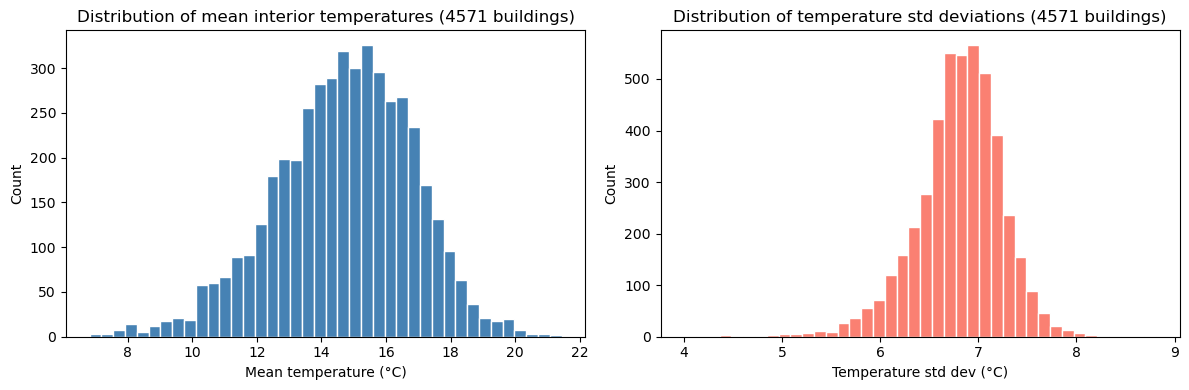

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['mean_temp'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Mean temperature (°C)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of mean interior temperatures (4571 buildings)')

axes[1].hist(df['std_temp'], bins=40, color='salmon', edgecolor='white')
axes[1].set_xlabel('Temperature std dev (°C)')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of temperature std deviations (4571 buildings)')

plt.tight_layout()
plt.savefig('hist_mean_temp.png', dpi=150, bbox_inches='tight')
plt.show()

##### **12.2 What is the average mean temperature of the buildings?**


In [11]:
avg_mean = df['mean_temp'].mean()
avg_mean

14.69416455970602

##### **12.3 What is the average temperature standard deviation?**


In [12]:
avg_std = df['std_temp'].mean()
avg_std

6.801602676111526

##### **12.4 How many buildings had at least 50% of their area above 18°C?**


In [13]:
n_above = (df['pct_above_18'] >= 50).sum()
n_above

804

##### **12.5 How many buildings had at least 50% of their area below 15°C?**


In [14]:
n_below = (df['pct_below_15'] >= 50).sum()
n_below

2471